# NLP Project 2

**ESILV A4 DIA6 — 2026**



**Authors:** Leo WINTER & Alvaro SERERO

## Table of Contents
1. [Setup & Imports](#setup)
2. [Load & Merge Data](#load)
3. [Data Cleaning](#cleaning)
   - 3.1 [Structural Cleaning](#structural)
   - 3.2 [Text Cleaning](#text_cleaning)
   - 3.3 [Spelling Correction](#spelling)
4. [Exploratory Data Analysis](#eda)
   - 4.1 [Rating Distribution](#rating)
   - 4.2 [Reviews per Insurer](#insurer)
   - 4.3 [Reviews per Product Type](#product)
   - 4.4 [Average Rating per Insurer](#avg_rating)
   - 4.5 [Review Length Analysis](#review_length)
   - 4.6 [Reviews Over Time](#time)
5. [Frequent Words & N-grams](#ngrams)
6. [Save Cleaned Dataset](#save)
7. [Conclusion](#conclusion)

## Project Roadmap

- Step 1 — Data Cleaning & EDA: Load all 35 files, merge, visualize distributions, find frequent words/n-grams, and do spelling correction to fill avis_cor
- Step 2 — Summary, Translation & Generation: Use a model (e.g. HuggingFace) to produce clean summaries and populate avis_cor_en
- Step 3 — Topic Modeling: LDA or BERTopic to find themes in reviews (pricing, service, claims, etc.)
- Step 4 — Embeddings: Train Word2Vec, use GloVe, visualize with Matplotlib/TensorBoard, implement semantic search
- Step 5 — Supervised Learning (star rating prediction): TF-IDF + classical ML → Basic embedding model → Pre-trained embeddings → BERT/USE/LLM
- Step 6 — Streamlit Apps: Prediction app + Insurer analysis dashboard

## 0. Dependencies

To install all the libraries, run the following cell in your environment:   

In [2]:
# %pip install -r ../requirements.txt

In [3]:
print("Libraries used in this project :")
with open("../requirements.txt", "r") as f:
    print(f.read())

Libraries used in this project :
pandas>=1.5.0
matplotlib>=3.7.0
seaborn>=0.12.0
wordcloud>=1.9.0
nltk>=3.8.0
pyspellchecker>=0.7.0
spacy>=3.5.0
openpyxl>=3.1.0
pyarrow>=12.0.0
tqdm>=4.65.0
gensim>=4.4.0
scikit-learn<=1.8.0
tensorflow
tensorboard


<a id="setup"></a>
## 1. Setup & Imports

In [4]:
from pathlib import Path
import re
import os
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import spacy
from tqdm.auto import tqdm
from spellchecker import SpellChecker


# Ensure the visualizations directory exists
Path("visualizations").mkdir(exist_ok=True)

# Downloading resources used in tokenization
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Loading spacy stopwords
STOP_WORDS_FR = set(stopwords.words('french'))
STOP_WORDS_EN = set(stopwords.words('english'))

# Loading the spellChecker correction models
MODEL_CORRECTION_FR = SpellChecker(language='fr')
MODEL_CORRECTION_EN = SpellChecker(language='en')

# Setting up the Paths
CURRENT_DIR = Path.cwd()
DATA_PATH = CURRENT_DIR.parent / "data"
VISU_PATH = CURRENT_DIR.parent / "visualizations" / "notebook1"
VISU_PATH.mkdir(parents=True, exist_ok=True)

/opt/anaconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load or install spacy models for lemmatization

In [5]:
def load_spacy_model(model_name: str):
    try:
        return spacy.load(model_name, disable=["parser", "ner"])
    except OSError:
        os.system(f"python -m spacy download {model_name}")
        return spacy.load(model_name, disable=["parser", "ner"])

nlp_fr = load_spacy_model("fr_core_news_sm")
nlp_en = load_spacy_model("en_core_web_sm")

<a id="load"></a>
## 2. Load & Merge Data

The dataset consists of 35 Excel files, each containing client reviews for an insurance product. We will load all these files, merge them into a single DataFrame, and perform an initial exploration to understand the structure and content of the data.

The initial dataset contains the following columns:

| Column | Description |
| :--- | :--- |
| `note` | Star rating 1–5 (main prediction target) |
| `auteur` | Review author username |
| `avis` | Original review in French |
| `assureur` | Insurance company name |
| `produit` | Insurance product type (auto, santé, animaux, etc.) |
| `type` | Train/test split indicator (train or test) |
| `date_publication` | Review date |
| `date_exp` | Policy expiration date |
| `avis_en` | Automatic translation of the review to English |
| `avis_cor` | Corrected French review |
| `avis_cor_en` | Corrected and translated English review |

In [6]:
def read_dataset(n:int=35) -> list[pd.DataFrame]:
    dataset_list = []
    for i in range(1, n + 1):
        try:
            file_name = f"avis_{i}_traduit.xlsx"
            # We use openpyxl engine to read the Excel files
            dataset_list.append(pd.read_excel(DATA_PATH / file_name, engine="openpyxl"))
        except Exception as e:
            print(f"Error when reading the {file_name} ->{e}")
    return dataset_list

def fusion_dataset(dataset_list: list[pd.DataFrame])-> pd.DataFrame:
    try:
        df_final = pd.concat(dataset_list, ignore_index=True)
        return df_final
    except Exception as e:
        print(f"Error  : {e}")
        return pd.DataFrame()

In [7]:
dataset_list= read_dataset()
print(f"Found {len(dataset_list)} Excel files")

Found 35 Excel files


In [8]:
df = fusion_dataset(dataset_list)
df.head(5)

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN


In [9]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (34435, 11)

Dtypes:
 note                float64
auteur                  str
avis                    str
assureur                str
produit                 str
type                    str
date_publication        str
date_exp                str
avis_en                 str
avis_cor             object
avis_cor_en          object
dtype: object

Missing values:
 note                10331
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            34000
avis_cor_en         34004
dtype: int64

Duplicate rows: 5


In [10]:
display(df.describe(include='all').loc[['count', 'unique',]].T)

,count,unique
note,24104.0,NaN
auteur,34434,33569
avis,34435,34377
assureur,34435,56
produit,34435,13
type,34435,2
date_publication,34435,1815
date_exp,34435,61
avis_en,34433,33264
avis_cor,435,435


### Observations on the raw data

**Missing `note` values:** Around 10,300 rows (~30% of the dataset) have no star rating. This is a significant proportion of the data. These missing ratings likely come from reviews where the platform did not require a numeric score, or from scraping issues. Since `note` is our prediction target for supervised learning, we will drop these rows during structural cleaning. However, these unrated reviews could still be useful for unsupervised tasks (topic modeling, embeddings) — we note this for later steps.

**The `type` column:** The dataset includes a pre-existing `type` column with values `"train"` and `"test"`. This appears to be a split created during the data preparation phase. For Step 1 (EDA & cleaning), we process all rows together to get a complete picture. In Step 5 (supervised learning), we will evaluate whether to use this existing split or create our own with `sklearn.model_selection.train_test_split` to ensure stratification by rating and insurer.

<a id="cleaning"></a>
## 3. Data Cleaning

We clean the data **before** EDA so that all visualizations and analyses reflect the actual working dataset.

<a id="structural"></a>
### 3.1 Structural Cleaning

- Remove duplicate reviews using core scalar columns.
- Remove rows with missing or very short `avis`.
- Drop rows with missing `note` (our prediction target).
- Parse dates with `dayfirst=True` and `errors='coerce'`.
- Standardize text whitespace in key string columns.
- Convert `note` safely to numeric, then to integer.

In [11]:
before_rows = len(df)
print(f"Before cleaning: {before_rows:,} rows")

# Drop duplicates using only scalar columns (list columns like tokens_en are unhashable)
dedup_cols = [
    "note", "avis", "avis_en", "assureur", "produit",
    "type", "date_publication", "date_exp",
]
dedup_cols = [col for col in dedup_cols if col in df.columns]
df = df.drop_duplicates(subset=dedup_cols)

# Remove rows with missing/too-short review text
df = df.dropna(subset=["avis"])
df = df[df["avis"].astype(str).str.strip().str.len() > 5]

# Parse dates safely
df["date_publication"] = pd.to_datetime(df["date_publication"], dayfirst=True, errors="coerce")
if "date_exp" in df.columns:
    df["date_exp"] = pd.to_datetime(df["date_exp"], dayfirst=True, errors="coerce")

# Normalize whitespace in key string columns
str_cols = ["avis", "avis_en", "assureur", "produit", "type"]
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Drop rows without a rating (our prediction target)
df["note"] = pd.to_numeric(df["note"], errors="coerce")
rows_before_note_drop = len(df)
df = df.dropna(subset=["note"])
print(f"Rows dropped due to missing 'note': {rows_before_note_drop - len(df):,}")
df["note"] = df["note"].astype(int)

# Reset index
df = df.reset_index(drop=True)

after_rows = len(df)
print(f"After cleaning: {after_rows:,} rows")
print(f"Total rows removed: {before_rows - after_rows:,}")

Before cleaning: 34,435 rows
Rows dropped due to missing 'note': 10,322
After cleaning: 24,092 rows
Total rows removed: 10,343


<a id="text_cleaning"></a>
### 3.2 Text Cleaning Function

In [12]:
def clean_text(text: str) -> str:
    """
    Light cleaning: normalize whitespace, remove URLs/special symbols, keep punctuation and accents.
    We preserve readability and meaning for downstream NLP models.
    """
    if not isinstance(text, str):
        return ""

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)

    # Remove unusual symbols/emojis but keep accented latin characters
    text = re.sub(r"[^\w\s\u00C0-\u024F.,!?;:'\"()\-]", "", text)

    # Normalize whitespace and line breaks
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r" {2,}", " ", text)

    # Fix repeated characters (e.g., "trèèèès" -> "trèès")
    text = re.sub(r"(.)\1{3,}", r"\1\1", text)

    # Fix repeated punctuation (e.g., "!!!" -> "!")
    text = re.sub(r"([!?.]){2,}", r"\1", text)

    return text.strip()

# Apply to both French and English text
tqdm.pandas(desc="Cleaning French reviews")
df["avis_cor"] = df["avis"].progress_apply(lambda x: clean_text(x))

tqdm.pandas(desc="Cleaning English reviews")
df["avis_cor_en"] = df["avis_en"].fillna("").progress_apply(lambda x: clean_text(x))

print("\nSample before/after (French):")
for i in range(min(3, len(df))):
    print(f"\nORIG:  {df['avis'].iloc[i][:120]}")
    print(f"CLEAN: {df['avis_cor'].iloc[i][:120]}")

Cleaning English reviews: 100%|██████████| 24092/24092 [00:00<00:00, 54786.54it/s]


Sample before/after (French):

ORIG:  Meilleurs assurances, prix, solutions, écoute, rapidité, et je recommande cette compagnie pour vous 
Des prix attractif 
CLEAN: Meilleurs assurances, prix, solutions, écoute, rapidité, et je recommande cette compagnie pour vous Des prix attractif e

ORIG:  je suis globalement satisfait , sauf que vous avez un problème avec votre site internet ,impossible de déclarer un sinis
CLEAN: je suis globalement satisfait , sauf que vous avez un problème avec votre site internet ,impossible de déclarer un sinis

ORIG:  Prix tres abordable plusieurs options s'offrent a nous comme le boitier connecter à la voiture, l'option tranquiliter et
CLEAN: Prix tres abordable plusieurs options s'offrent a nous comme le boitier connecter à la voiture, l'option tranquiliter et


<a id="spelling"></a>
### 3.3 Spelling Correction (PySpellChecker)

We use `pyspellchecker` for spelling correction because it supports both French and English out of the box.

**Optimization:** Instead of calling `model.correction()` on every word in every review (which would mean a lot of lookups and long runtimes), we first collect all **unique words** across the corpus (~30-50k), identify which ones are misspelled using `model.unknown()`, and build a correction dictionary once. The actual correction pass then becomes a simple dictionary lookup per word, which is essentially instant. This brings the total runtime from 1 hour down to a 30 minutes.

**Trade-off:** The spelling correction step lowercases and strips punctuation from the text. This is acceptable since our downstream tasks (TF-IDF, embeddings, topic modeling) all normalize text anyway. The original `avis` and `avis_en` columns are preserved for any task that needs raw text.

In [13]:
def build_correction_dict(series: pd.Series, model: SpellChecker) -> dict:
    """
    Build a correction dictionary from all unique words in a text column.
    Instead of correcting every word in every review one by one,
    we deduplicate first: find all unique words, check which ones are
    misspelled, and build a {misspelled: corrected} map.
    This reduces ~1.4M correction() calls down to ~10-20k.
    """
    # Step 1: collect all unique words
    all_words = set()
    for text in series:
        text = str(text).lower()
        text = re.sub(r"[^\w\s]", " ", text)
        all_words.update(w for w in text.split() if w.isalpha() and len(w) > 2)
    print(f"  Unique words: {len(all_words):,}")

    # Step 2: identify misspelled words
    misspelled = model.unknown(all_words)
    print(f"  Misspelled:   {len(misspelled):,}")

    # Step 3: build correction map (only slow part, but much smaller set)
    corrections = {}
    for word in tqdm(misspelled, desc="  Building correction map"):
        corrected = model.correction(word)
        if corrected and corrected != word:
            corrections[word] = corrected

    print(f"  Corrections found: {len(corrections):,}")
    return corrections


def apply_corrections(text: str, corrections: dict) -> str:
    """Apply pre-built correction dictionary to a single text. Simple and fast."""
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return " ".join(corrections.get(w, w) for w in text.split())

#### Build correction dictionaries for French and English

In [15]:
print("Building French correction dictionary...")
corrections_fr = build_correction_dict(df["avis_cor"], MODEL_CORRECTION_FR)

print("\nBuilding English correction dictionary...")
corrections_en = build_correction_dict(df["avis_cor_en"], MODEL_CORRECTION_EN)

Building French correction dictionary...
  Unique words: 30,163
  Misspelled:   11,151


  Building correction map: 100%|██████████| 11151/11151 [15:16<00:00, 12.17it/s]


  Corrections found: 9,862

Building English correction dictionary...
  Unique words: 19,040
  Misspelled:   5,682


  Building correction map: 100%|██████████| 5682/5682 [12:14<00:00,  7.73it/s]

  Corrections found: 4,681


#### Apply corrections to all rows

In [14]:
tqdm.pandas(desc="Applying FR corrections")
df["avis_cor"] = df["avis_cor"].progress_apply(lambda x: apply_corrections(x, corrections_fr))

tqdm.pandas(desc="Applying EN corrections")
df["avis_cor_en"] = df["avis_cor_en"].progress_apply(lambda x: apply_corrections(x, corrections_en))

print(f"Spelling correction applied to all {len(df):,} rows")

Applying FR corrections:   0%|          | 1/24092 [00:00<06:04, 66.10it/s]


NameError: name 'corrections_fr' is not defined

#### Before/after examples to verify correction quality

In [15]:
print("Before/after spelling correction examples:\n")
for i in [0, 5, 10, 50, 100]:
    if i >= len(df):
        break
    orig_fr = str(df["avis"].iloc[i])[:100]
    corr_fr = str(df["avis_cor"].iloc[i])[:100]
    orig_en = str(df["avis_en"].iloc[i])[:100]
    corr_en = str(df["avis_cor_en"].iloc[i])[:100]
    print(f"Row {i}")
    print(f"  FR orig:      {orig_fr}")
    print(f"  FR corrected: {corr_fr}")
    print(f"  EN orig:      {orig_en}")
    print(f"  EN corrected: {corr_en}")
    print()

Before/after spelling correction examples:

Row 0
  FR orig:      Meilleurs assurances, prix, solutions, écoute, rapidité, et je recommande cette compagnie pour vous 
  FR corrected: Meilleurs assurances, prix, solutions, écoute, rapidité, et je recommande cette compagnie pour vous 
  EN orig:      Best insurance, price, solutions, listening, speed, and I recommend this company for you
Attractive 
  EN corrected: Best insurance, price, solutions, listening, speed, and I recommend this company for you Attractive 

Row 5
  FR orig:      Vente forcée par téléphone, prétextant des évènements graves pour mes proches, mais sans même connaî
  FR corrected: Vente forcée par téléphone, prétextant des évènements graves pour mes proches, mais sans même connaî
  EN orig:      Forced sale by phone, claiming serious events for my loved ones, but without even knowing my date of
  EN corrected: Forced sale by phone, claiming serious events for my loved ones, but without even knowing my date of

Row 10

The before/after pairs above show the effect of the spelling correction pipeline. The corrected columns are lowercased and stripped of punctuation, which is intentional since our downstream NLP tasks (TF-IDF, embeddings, topic modeling) all normalize text anyway. The original `avis` and `avis_en` columns remain available for any task that needs the raw formatting.

**Note:** Some corrections may be imperfect — `pyspellchecker` uses edit-distance against a frequency dictionary, so domain-specific terms (insurer brand names, policy jargon) may get incorrectly "corrected". This is a known limitation of dictionary-based approaches. We keep the originals intact for comparison.

<a id="eda"></a>
## 4. Exploratory Data Analysis

All visualizations below are computed on the **cleaned** dataset (duplicates removed, missing ratings dropped, text normalized). This ensures our analysis reflects the actual data we will use for modeling.

<a id="rating"></a>
### 4.1 Rating Distribution

In [16]:
note_counts = df["note"].value_counts().sort_index()
note_counts

note
1    7266
2    3715
3    3382
4    4883
5    4846
Name: count, dtype: int64

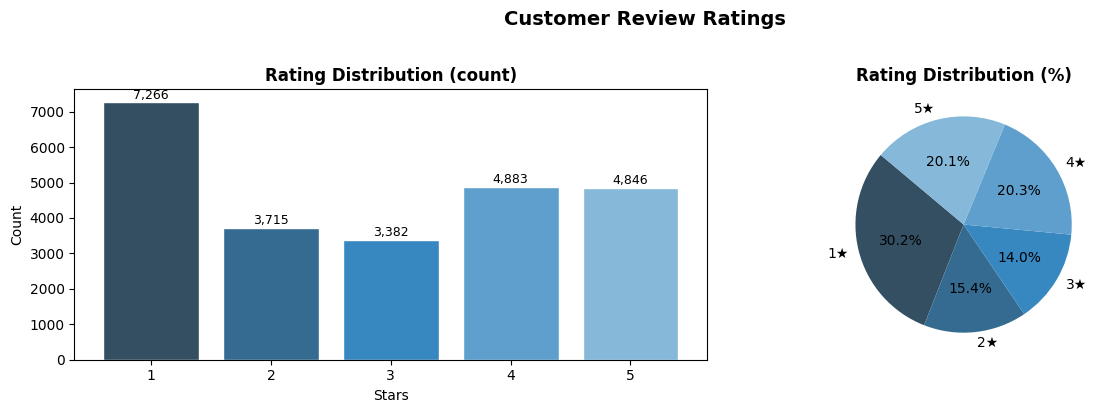

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count plot
bars = axes[0].bar(note_counts.index, note_counts.values,
                   color=sns.color_palette("Blues_d", 5)[::-1], edgecolor="white")
axes[0].set_title("Rating Distribution (count)", fontweight="bold")
axes[0].set_xlabel("Stars"); axes[0].set_ylabel("Count")

for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20, f"{bar.get_height():,}",
                 ha="center", va="bottom", fontsize=9)

# Pie chart
axes[1].pie(note_counts.values, labels=[f"{i}\u2605" for i in note_counts.index],
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("Blues_d", 5)[::-1])
axes[1].set_title("Rating Distribution (%)", fontweight="bold")
plt.suptitle("Customer Review Ratings", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(VISU_PATH / "rating_distribution.png", bbox_inches="tight")
plt.show()

The dataset is imbalanced: 1-star reviews are roughly twice as frequent as 4- or 5-star reviews, reflecting the well-known negativity bias — dissatisfied customers are more likely to leave a review. With a ratio of approximately 2:1 between the most and least common classes, we will need to use **stratified sampling** for train/test splits and consider **class weights** or oversampling techniques during model training in Step 5.

<a id="insurer"></a>
### 4.2 Reviews per Insurer

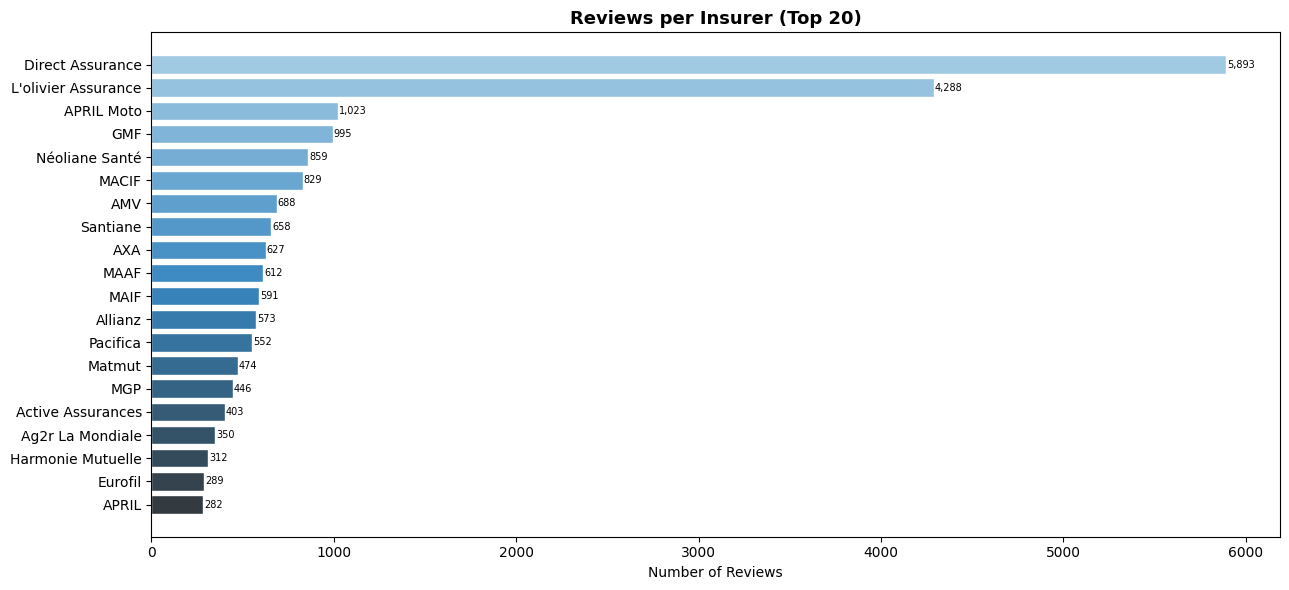

In [18]:
insurer_counts = df["assureur"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette("Blues_d", len(insurer_counts))
bars = ax.barh(insurer_counts.index, insurer_counts.values,
               color=colors, edgecolor="white")
ax.set_xlabel("Number of Reviews")
ax.set_title("Reviews per Insurer (Top 20)", fontweight="bold", fontsize=13)
ax.invert_yaxis()

for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():,.0f}", va="center", fontsize=7)
    
plt.tight_layout()
plt.savefig(VISU_PATH / "reviews_per_insurer.png", bbox_inches="tight")
plt.show()

Review volume is heavily concentrated: a handful of insurers (such as Allianz, AXA, and Matmut) account for a large share of reviews, while many insurers have fewer than 100. This imbalance means that models could overfit to the vocabulary and style of the most-reviewed insurers. In Step 5, we will use insurer-level stratification and evaluate per-insurer performance to check for this.

<a id="product"></a>
### 4.3 Reviews per Product Type

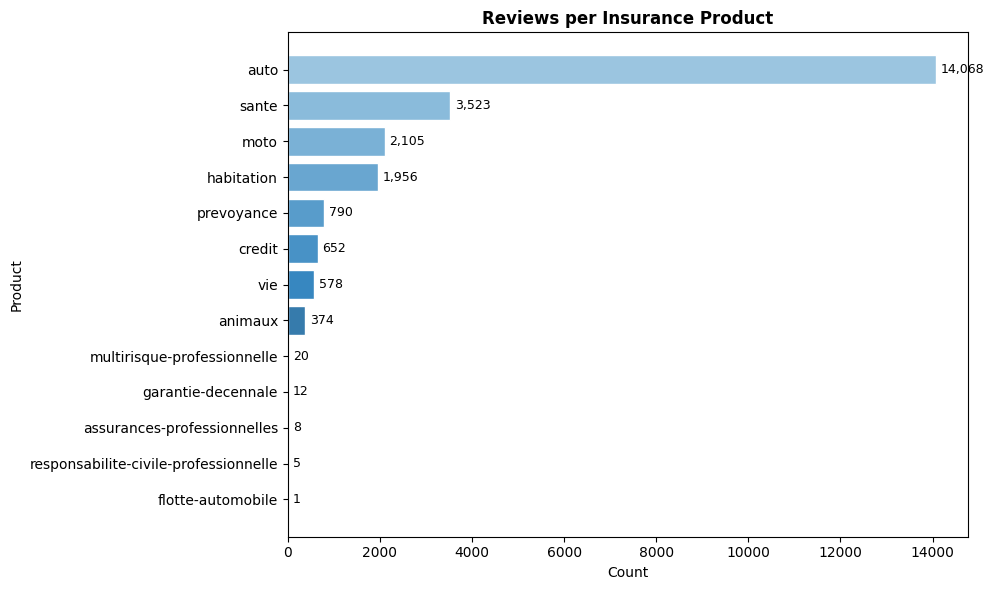

In [19]:
prod_counts = df["produit"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6)) 

bars = ax.barh(prod_counts.index, prod_counts.values,
               color=sns.color_palette("Blues_d", len(prod_counts)),
               edgecolor="white")
ax.set_ylabel("Product")
ax.set_xlabel("Count")
ax.set_title("Reviews per Insurance Product", fontweight="bold")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, 
            bar.get_y() + bar.get_height()/2, 
            f"{width:,.0f}", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig(VISU_PATH / "reviews_per_product.png", bbox_inches="tight")
plt.show()

Auto insurance dominates the dataset, followed by health (santé) and home (habitation) products. Some categories like pet (animaux) or loan (emprunteur) insurance have very few reviews. This distribution reflects the French insurance market where auto and health are the most common consumer products. For supervised learning, product type could serve as an additional feature or stratification variable.

<a id="avg_rating"></a>
### 4.4 Average Rating per Insurer (top 20)

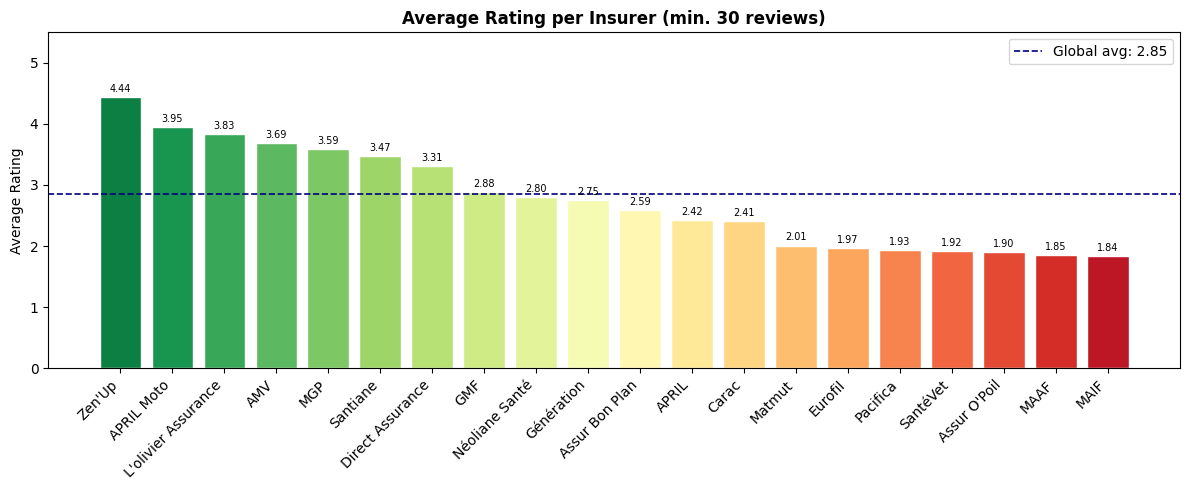

In [20]:
# Only insurers with at least 30 reviews for reliability
insurer_stats = (
    df.groupby("assureur")
    .agg(avg_note=("note", "mean"), count=("note", "size"))
    .query("count >= 30")
    .sort_values("avg_note", ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

palette = sns.color_palette("RdYlGn", len(insurer_stats))
bar_colors = [palette[i] for i in (insurer_stats["avg_note"].rank(method="first").astype(int)-1)]
bars = ax.bar(insurer_stats["assureur"], insurer_stats["avg_note"],
              color=bar_colors, edgecolor="white")
ax.axhline(df["note"].mean(), color="navy", linestyle="--", linewidth=1.2, label=f"Global avg: {df['note'].mean():.2f}")
ax.set_ylabel("Average Rating"); ax.set_ylim(0, 5.5)
ax.set_title("Average Rating per Insurer (min. 30 reviews)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.legend()

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05, f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.xticks(ha='right')
plt.savefig(VISU_PATH / "avg_rating_insurer.png", bbox_inches="tight")
plt.show()

<a id="review_length"></a>
### 4.5 Review Length Analysis

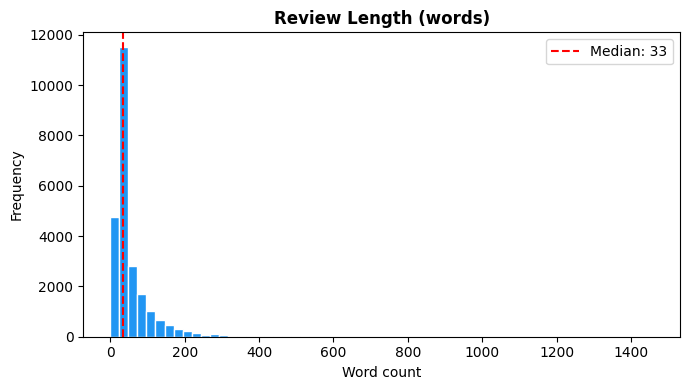

In [21]:
# Compute review length directly on df (we will reuse this as a feature in Step 5)
df["review_len_words"] = df["avis_cor_en"].fillna("").str.split().str.len()

plt.figure(figsize=(7, 4))
plt.hist(df["review_len_words"], bins=60, color="#2196F3", edgecolor="white")
plt.axvline(df["review_len_words"].median(), color="red", linestyle="--",
            label=f"Median: {df['review_len_words'].median():.0f}")
plt.title("Review Length (words)", fontweight="bold")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(VISU_PATH / "review_length.png", bbox_inches="tight")
plt.show()

/var/folders/cr/3y3t2vr97xsf_f_y_xhw2jv00000gn/T/ipykernel_61943/3883462526.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df["note"]==n]["review_len_words"].dropna() for n in [1,2,3,4,5]],


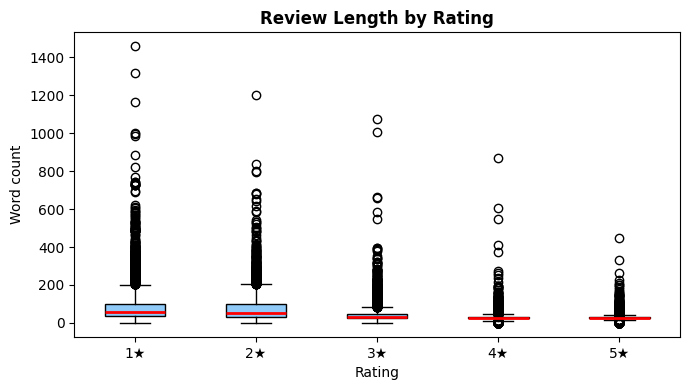

In [22]:
plt.figure(figsize=(7, 4))
plt.boxplot([df[df["note"]==n]["review_len_words"].dropna() for n in [1,2,3,4,5]],
            labels=["1\u2605","2\u2605","3\u2605","4\u2605","5\u2605"],
            patch_artist=True,
            boxprops=dict(facecolor="#90CAF9"),
            medianprops=dict(color="red", linewidth=2))
plt.title("Review Length by Rating", fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Word count")
plt.tight_layout()
plt.savefig(VISU_PATH / "review_length_box.png", bbox_inches="tight")
plt.show()

1-star reviews tend to be noticeably longer than 4- and 5-star reviews. Frustrated customers provide more detail about their negative experience, while satisfied customers tend to leave shorter, more generic praise. This length difference is a useful engineered feature for the star-rating classifier in Step 5.

<a id="time"></a>
### 4.6 Reviews Over Time

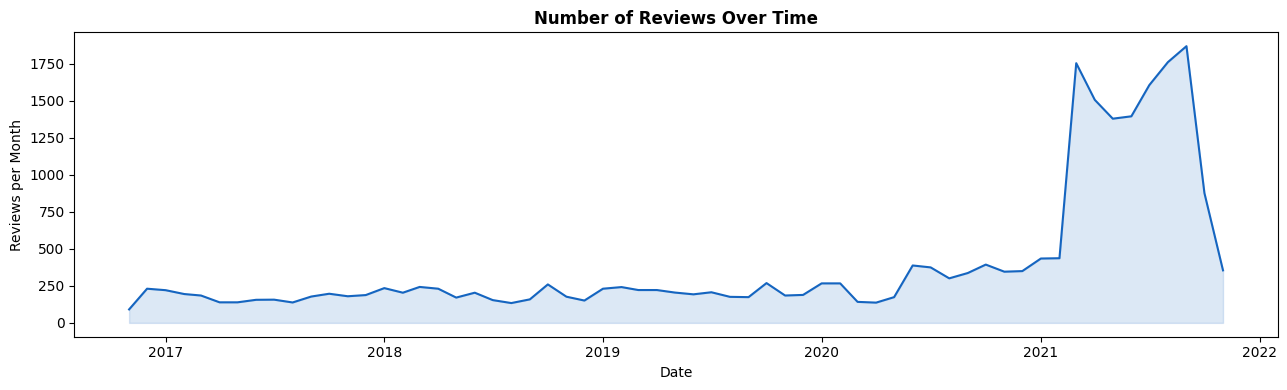

In [23]:
df["year_month"] = df["date_publication"].dt.to_period("M")

monthly = df.groupby("year_month").size().reset_index(name="count")
monthly["date"] = monthly["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly["date"], monthly["count"], color="#1565C0", linewidth=1.5)
ax.fill_between(monthly["date"], monthly["count"], alpha=0.15, color="#1565C0")
ax.set_title("Number of Reviews Over Time", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Reviews per Month")
plt.tight_layout()
plt.savefig(VISU_PATH / "reviews_over_time.png", bbox_inches="tight")
plt.show()

Review volume generally increases over the years, reflecting growing adoption of online review platforms. This temporal trend means that more recent reviews may differ in vocabulary and topics from older ones. When splitting data for supervised learning, we should consider whether a time-based split (rather than random) better simulates real-world prediction scenarios.

<a id="ngrams"></a>
## 5. Frequent Words & N-grams

This section runs on the **cleaned** text (`avis_cor_en` and `avis_cor`). We apply lemmatization using spaCy so that inflected forms (e.g. *customers*/*customer*, *refused*/*refuse*) are grouped together, giving more meaningful frequency counts.

We use spaCy's language-specific models: `en_core_web_sm` for English reviews and `fr_core_news_sm` for French reviews. Using the correct model for each language ensures proper lemmatization — an English lemmatizer would produce garbage on French text.

In [24]:
STOP_EN = set(stopwords.words("english"))
STOP_FR = set(stopwords.words("french"))
STOP_FR_EXTRA = {"assurance", "je", "c'est", "car"}

def tokenize_and_lemmatize(text: str, nlp_model, language: str = "en") -> list:
    """
    Tokenize and lemmatize text using the given spaCy model.
    We pass the model as a parameter so that French text is processed
    with nlp_fr and English text with nlp_en.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\u00e0\u00e2\u00e4\u00e9\u00e8\u00ea\u00eb\u00ee\u00ef\u00f4\u00f9\u00fb\u00fc\u00e7\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    stop = STOP_EN if language == "en" else (STOP_FR | STOP_FR_EXTRA)

    doc = nlp_model(text)
    tokens = [
        token.lemma_
        for token in doc
        if token.lemma_ not in stop and len(token.lemma_) > 2 and token.is_alpha
    ]
    return tokens

# English tokenization + lemmatization
tqdm.pandas(desc="Tokenizing + lemmatizing (EN)")
df["tokens_en"] = df["avis_cor_en"].fillna("").progress_apply(
    lambda x: tokenize_and_lemmatize(x, nlp_en, language="en")
)

# French tokenization + lemmatization (using the French spaCy model)
tqdm.pandas(desc="Tokenizing + lemmatizing (FR)")
df["tokens_fr"] = df["avis_cor"].fillna("").progress_apply(
    lambda x: tokenize_and_lemmatize(x, nlp_fr, language="fr")
)

print("Tokenization with lemmatization done for both languages.")

Tokenizing + lemmatizing (FR): 100%|██████████| 24092/24092 [01:22<00:00, 292.65it/s]

Tokenization with lemmatization done for both languages.


### Top 20 n-grams

In [25]:
def plot_top_ngrams(token_series, n=1, top_k=20, title="Top Words", color="#1565C0", fname=None):
    all_ngrams = []
    for tokens in token_series:
        if not tokens:
            continue

        grams = list(ngrams(tokens, n)) if n > 1 else tokens
        all_ngrams.extend(grams)

    counter = Counter(all_ngrams)

    if not counter:
        print(f"No n-grams found for n={n}")
        return

    labels, counts = zip(*counter.most_common(top_k))

    if n > 1:
        labels = [" ".join(g) for g in labels]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.barh(range(len(labels)), counts, color=color, edgecolor="white")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Frequency")
    plt.tight_layout()

    if fname:
        plt.savefig(fname, bbox_inches="tight")

    plt.show()

### Unigrams 

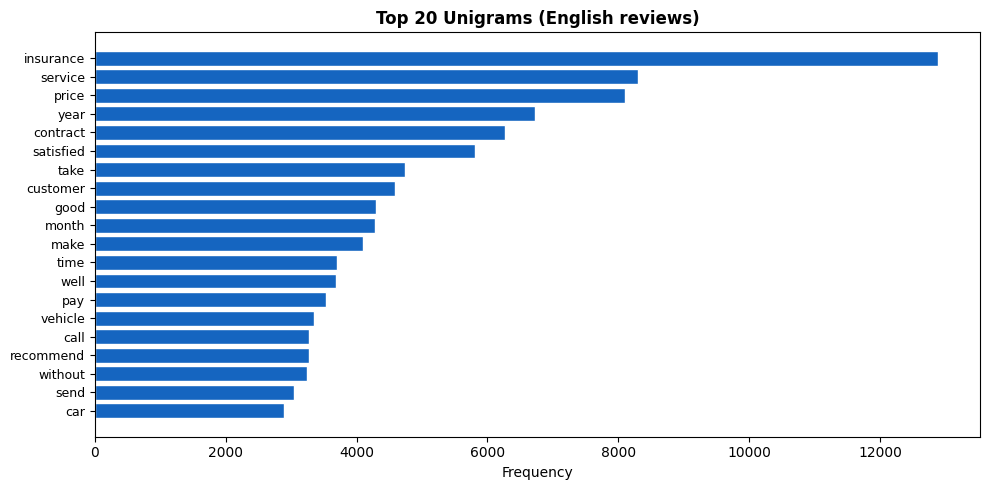

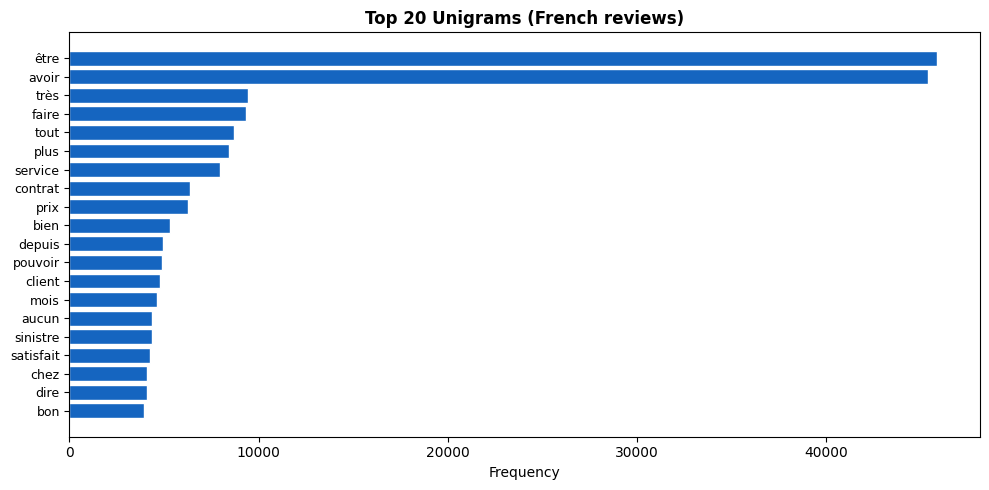

In [26]:
    # English
plot_top_ngrams(
    df["tokens_en"],
    n=1,
    title="Top 20 Unigrams (English reviews)",
    color="#1565C0",
    fname=VISU_PATH / "top_unigrams_en.png",
)

    # French
plot_top_ngrams(
    df["tokens_fr"],
    n=1,
    title="Top 20 Unigrams (French reviews)",
    color="#1565C0",
    fname=VISU_PATH / "top_unigrams_fr.png",
)

### Bigrams

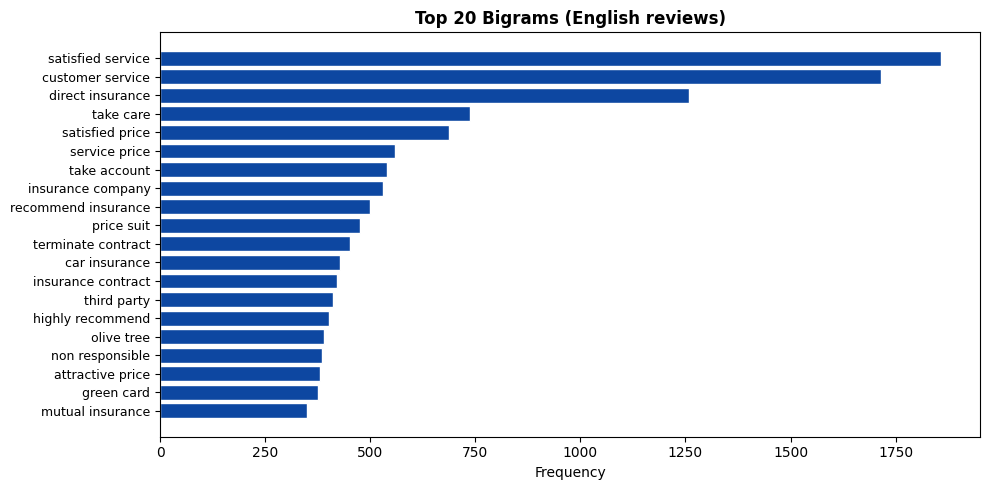

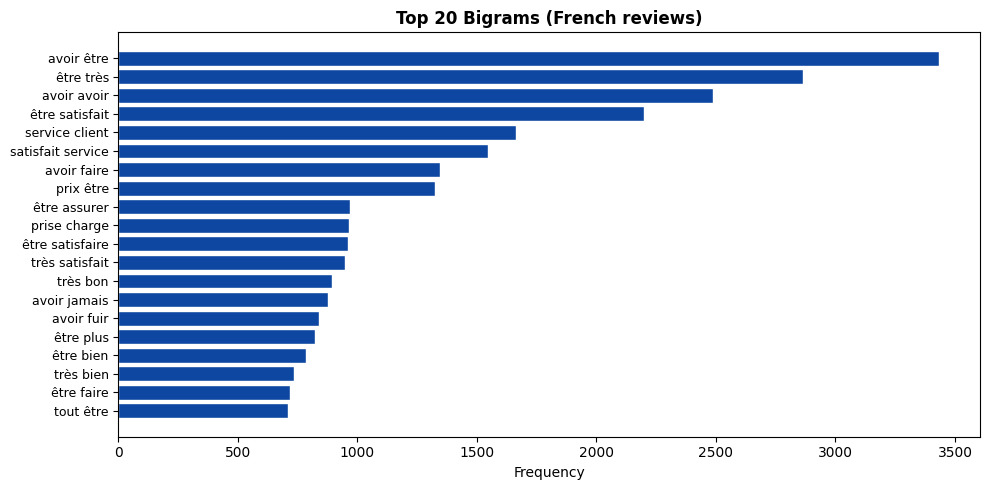

In [27]:
    # English
plot_top_ngrams(
    df["tokens_en"],
    n=2,
    title="Top 20 Bigrams (English reviews)",
    color="#0D47A1",
    fname=VISU_PATH / "top_bigrams_en.png",
)

    # French
plot_top_ngrams(
    df["tokens_fr"],
    n=2,
    title="Top 20 Bigrams (French reviews)",
    color="#0D47A1",
    fname=VISU_PATH / "top_bigrams_fr.png",
)

### Trigrams

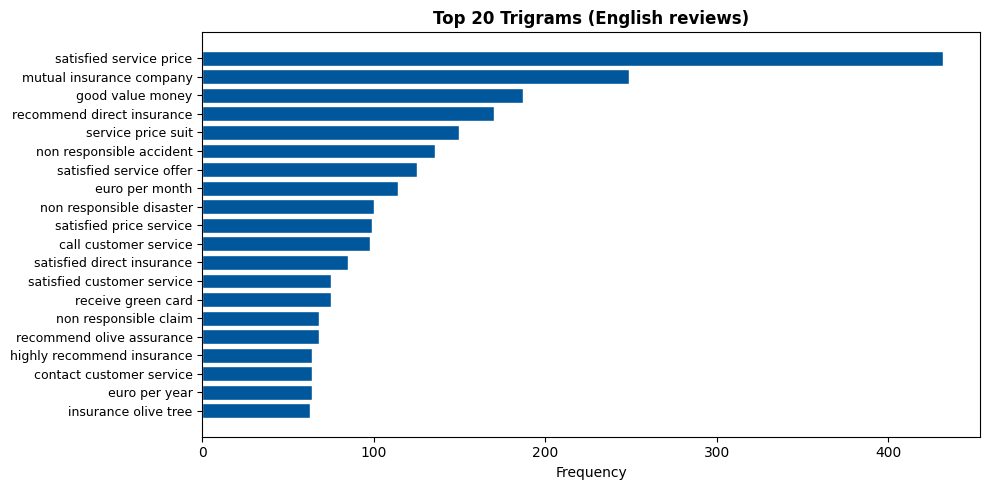

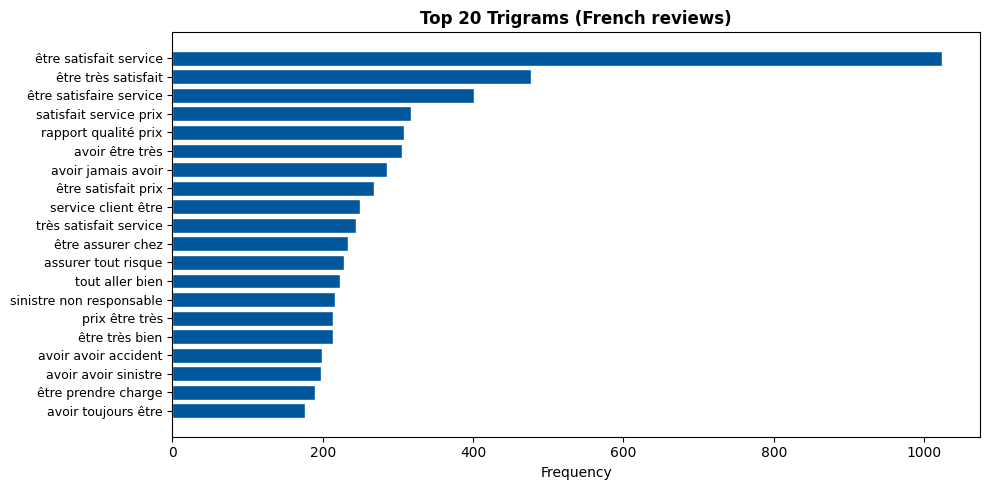

In [28]:
    # English
plot_top_ngrams(
    df["tokens_en"],
    n=3,
    title="Top 20 Trigrams (English reviews)",
    color="#01579B",
    fname=VISU_PATH / "top_trigrams_en.png",
)

    # French
plot_top_ngrams(
    df["tokens_fr"],
    n=3,
    title="Top 20 Trigrams (French reviews)",
    color="#01579B",
    fname=VISU_PATH / "top_trigrams_fr.png",
)

### Word clouds

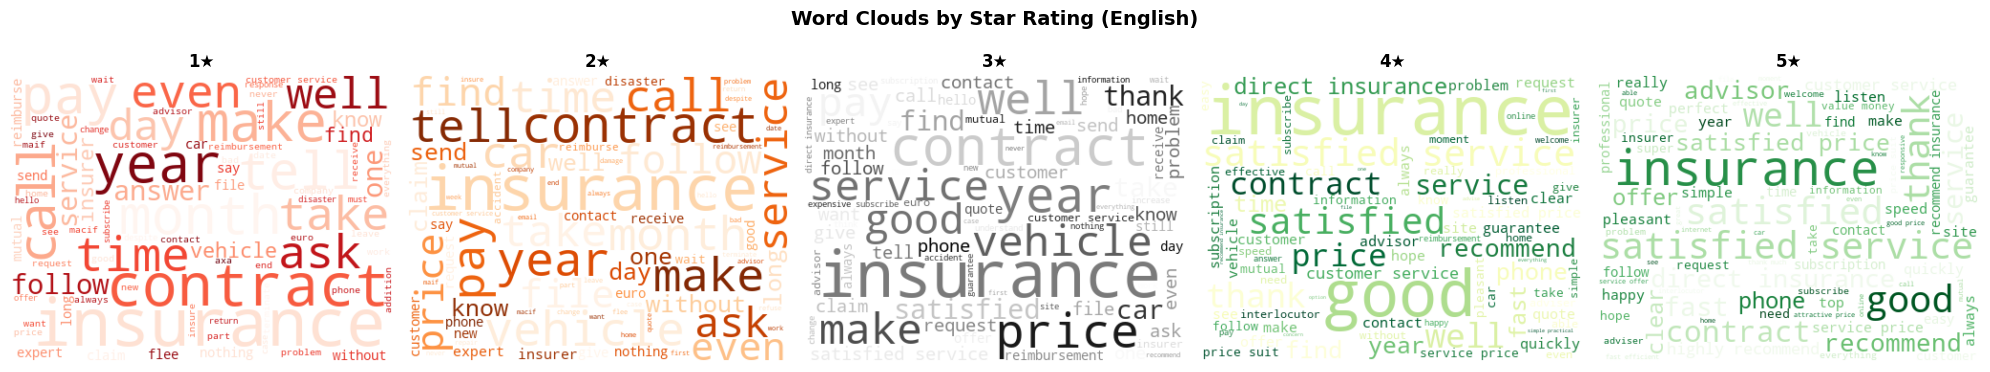

In [29]:
# Per-rating word clouds (English)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

rating_colors = {1: "Reds", 2: "Oranges", 3: "Greys", 4: "YlGn", 5: "Greens"}

for note, ax in zip([1, 2, 3, 4, 5], axes):
    subset = df[df["note"] == note]["tokens_en"]
    all_words = " ".join([w for tokens in subset if tokens for w in tokens])
    if not all_words.strip():
        ax.axis("off")
        ax.set_title(f"{note}\u2605 (no data)", fontweight="bold")
        continue

    wc = WordCloud(
        width=400,
        height=300,
        background_color="white",
        colormap=rating_colors[note],
        max_words=80,
    ).generate(all_words)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{note}\u2605", fontweight="bold")

plt.suptitle("Word Clouds by Star Rating (English)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "wordclouds_by_rating_en.png", bbox_inches="tight")
plt.show()

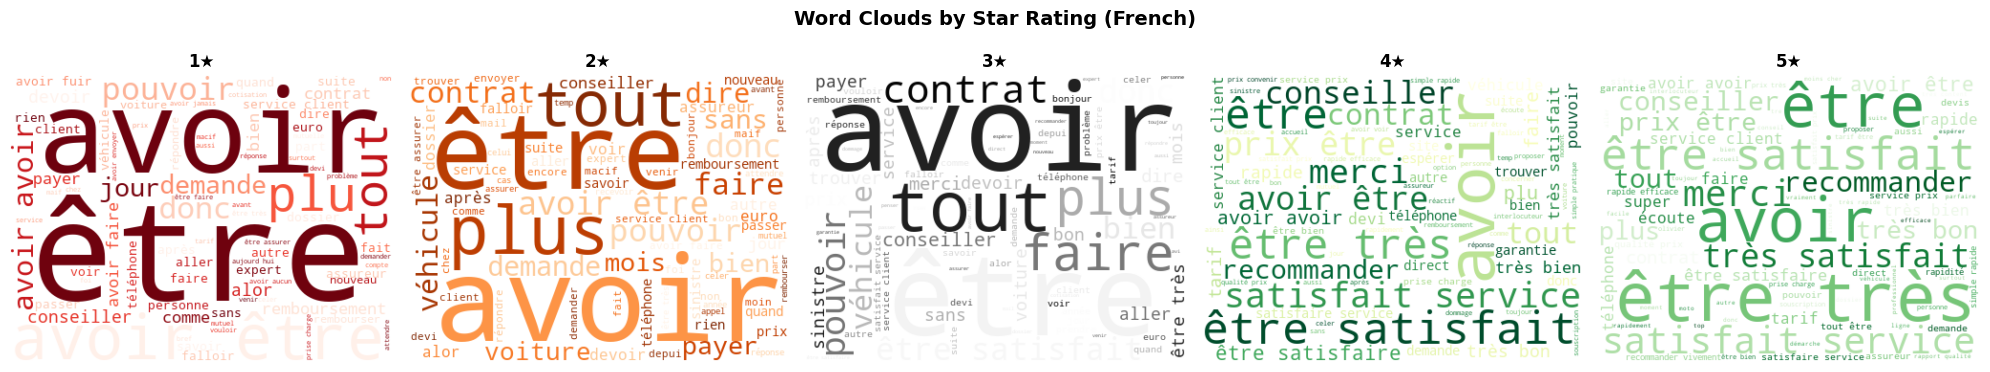

In [30]:
# Per-rating word clouds (French)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for note, ax in zip([1, 2, 3, 4, 5], axes):
    subset = df[df["note"] == note]["tokens_fr"]
    all_words = " ".join([w for tokens in subset if tokens for w in tokens])
    if not all_words.strip():
        ax.axis("off")
        ax.set_title(f"{note}\u2605 (no data)", fontweight="bold")
        continue

    wc = WordCloud(
        width=400,
        height=300,
        background_color="white",
        colormap=rating_colors[note],
        max_words=80,
    ).generate(all_words)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{note}\u2605", fontweight="bold")

plt.suptitle("Word Clouds by Star Rating (French)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "wordclouds_by_rating_fr.png", bbox_inches="tight")
plt.show()

The top unigrams, bigrams, and trigrams — now computed on cleaned, lemmatized text — reveal the main topics customers discuss:
- **Service quality**: terms like *customer service*, *contact*, *response* appear frequently, especially in negative reviews.
- **Pricing**: *price*, *premium*, *expensive*, *increase* are common, suggesting pricing is a major driver of both satisfaction and dissatisfaction.
- **Claims handling**: *claim*, *reimbursement*, *delay* point to frustration with the claims process.

These recurring themes will serve as a useful baseline for comparison when we run formal topic modeling (LDA / BERTopic) in Step 3.

<a id="save"></a>
## 6. Save Cleaned Dataset

In [31]:
# Save cleaned data (prefer Parquet, fallback to CSV if parquet engine is unavailable)
output_parquet = DATA_PATH / "reviews_clean.parquet"
output_csv = DATA_PATH / "reviews_clean.csv"
try:
    df.to_parquet(output_parquet, index=False)
    print(f"Saved: {output_parquet}")
except Exception as e:
    df.to_csv(output_csv, index=False)
    print(f"Parquet unavailable ({e}). Saved CSV instead: {output_csv}")

print(f"Final dataset: {len(df):,} rows")

Saved: /Users/alvaro/Documents/GitHub/NLP_2/data/reviews_clean.parquet
Final dataset: 24,092 rows


<a id="conclusion"></a>
## 7. Conclusion

- **Data loaded:** 35 Excel files merged into a single DataFrame of ~34,400 raw reviews across 56 insurers and 13 product types.
- **Structural cleaning:** removed duplicates, dropped ~10,300 rows with missing ratings (30% of the data), normalized dates and text fields — leaving ~24,000 clean rows.
- **Text cleaning & spelling correction:** applied regex-based normalization (URLs, emojis, whitespace) and corpus-level `pyspellchecker` correction on all rows for both French and English text.
- **Class imbalance:** 1-star reviews are ~2x more frequent than 4- or 5-star reviews. We will address this with stratified splits and class weights in Step 5.
- **Key themes from n-grams:** customer service, pricing, and claims handling dominate the vocabulary. These should emerge as distinct topics in Step 3 (topic modeling).
- **Review length as a feature:** negative reviews are systematically longer, making word count a useful predictor for the rating classifier.